In [457]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [458]:
# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

In [459]:
# Display the first ten rows of the dataset
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [460]:
# Output the names of the dataset's columns
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [461]:
# Display the data types of each column
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [462]:
# Convert the “TotalCharges” column to the numeric data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [463]:
# Remove rows with missing values from the dataset
df = df.dropna()

In [464]:
# Remove the “customerID” column from the dataset
df = df.drop(columns=["customerID"])

In [465]:
# Convert the “Churn” column to binary numeric values: replace “Yes” with 1 
# and “No” with 0
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

In [466]:
# Convert all categorical variables in the dataset into dummy variables. Store 
# the result in a new DataFrame called telecom_cust_dummies
telecom_cust_dummies = pd.get_dummies(df, drop_first=True)

# Print first 5 rows of telecom_cust_dummies
telecom_cust_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_1
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


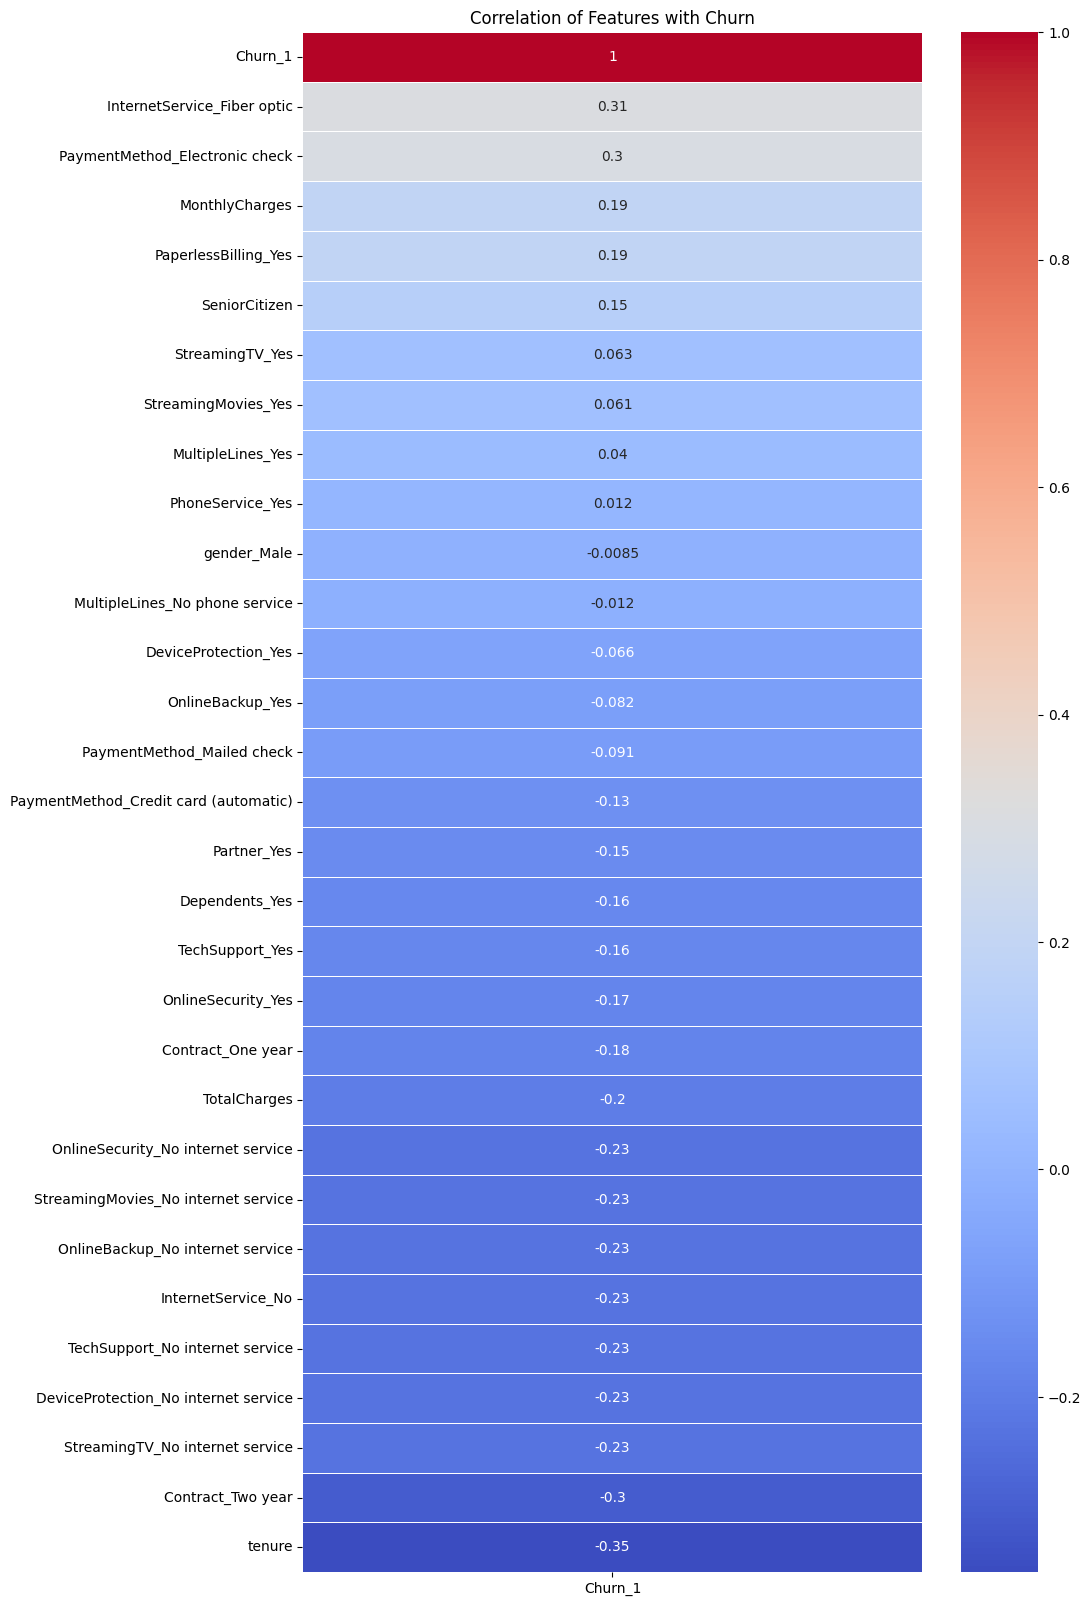

In [467]:
# Create a correlation plot to visualise the correlation between features and 
# the target variable “Churn”

# Calculate correlations
correlation_matrix = telecom_cust_dummies.corr()

# Sort correlations with respect to the target variable
churn_correlation = correlation_matrix[["Churn_1"]].sort_values(by="Churn_1", ascending=False)

# Create the correlation heatmap
plt.figure(figsize=(10, 20))

plt.title("Correlation of Features with Churn")

sns.heatmap(churn_correlation, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

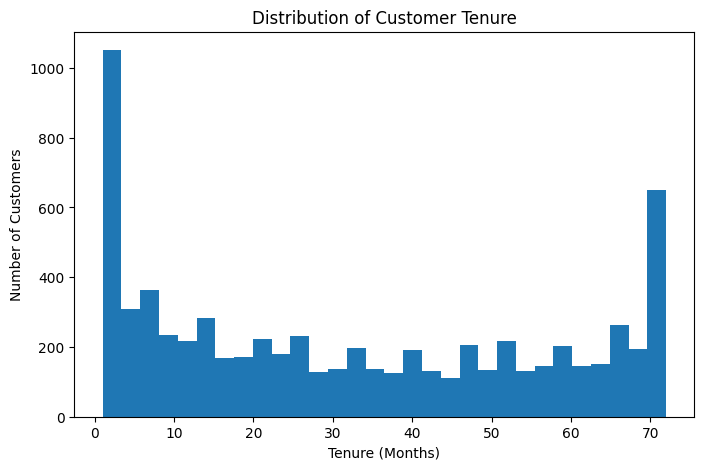

In [468]:
# Create a histogram of the “tenure” column
plt.figure(figsize=(8, 5))

plt.hist(df["tenure"], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

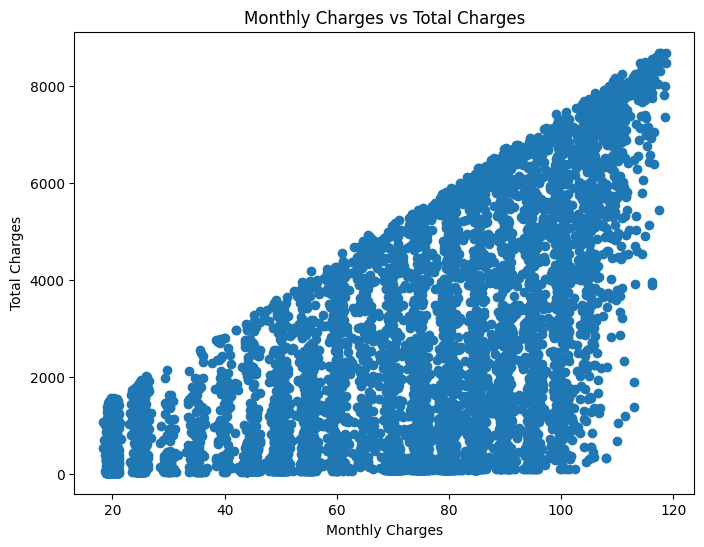

In [469]:
# Create a scatter plot of “MonthlyCharges” vs. “TotalCharges”
plt.figure(figsize=(8, 6))

plt.scatter(df["MonthlyCharges"], df["TotalCharges"])

plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")

plt.show()

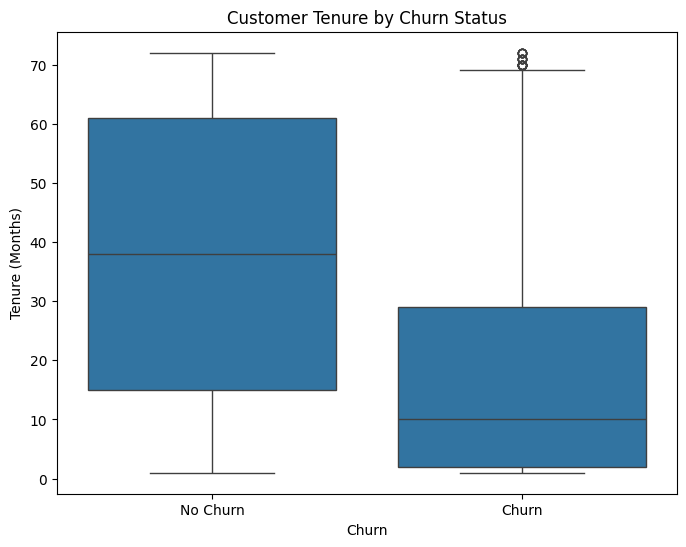

In [470]:
# Create a box plot to compare “tenure” for churned and non-churned 
# customers
plt.figure(figsize=(8, 6))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

# Rename x-axis labels to show if churn or not
plt.xticks([0, 1], ["No Churn", "Churn"])

plt.show()

In [471]:
# Scale all the variables to a range of 0 to 1 using min-max scaling

# Separate features and target variable
X = telecom_cust_dummies.drop("Churn_1", axis=1)
y = telecom_cust_dummies["Churn_1"]

# Create scaler object
scaler = MinMaxScaler()

# Fit and transform the feature variables
X_scaled = scaler.fit_transform(X)

# Convert scaled data back into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [472]:
# Split the dataset into training and test sets (X_train; X_test; y_train; y_test) 
# with a test size of 25%
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42)

In [473]:
# Import and train a logistic regression model on the training data

# Create logistic regression model
lm = LogisticRegression(max_iter=1000)

# Train the model
lm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [474]:
# Make predictions on the test data
y_pred_lm = lm.predict(X_test)

In [475]:
# Calculate and print the accuracy score of the logistic regression model
lm_accuracy = accuracy_score(y_test, y_pred_lm)
print("Logistic Regression Accuracy Score:", lm_accuracy)

Logistic Regression Accuracy Score: 0.7912400455062572


In [476]:
# Create a random forest classifier
rf = RandomForestClassifier(n_estimators=2000, oob_score=True, 
    max_features="sqrt", max_leaf_nodes=50, bootstrap=True, random_state=42)

In [477]:
# Fit the model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [478]:
# Make predictions on the new test data
y_pred_rf = rf.predict(X_test)

# Calculate and print the accuracy score of the random forest classifier
print(f'Testing Accuracy for Random Forest model: {accuracy_score(y_test, y_pred_rf)}')

Testing Accuracy for Random Forest model: 0.7935153583617748


In [479]:
# Calculate and print the OOB error estimation. Explain how well the model 
# generalises to unseen data

oob_error = 1 - rf.oob_score_

print("OOB Error Estimation:", oob_error)

OOB Error Estimation: 0.192643155100493


The low OOB error estimation shows that the model generalises unseen data wellm and is unlikely to be heavily overfitting the training data

In [480]:
# Implement code to calculate the confusion matrix for both the logistic 
# regression and random forest models

lm_conf_matrix = confusion_matrix(y_test, y_pred_log_reg)

print("Logistic Regression Confusion Matrix:\n", lm_conf_matrix)

rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)

print("\nRandom Forest Confusion Matrix:\n", rf_conf_matrix)

Logistic Regression Confusion Matrix:
 [[1154  146]
 [ 221  237]]

Random Forest Confusion Matrix:
 [[1187  113]
 [ 250  208]]


In [481]:
# Compute the precision and recall scores for each model
lm_precision = precision_score(y_test, y_pred_lm)

lm_recall = recall_score(y_test, y_pred_lm)

print("Logistic Regression Precision:", lm_precision)
print("\nLogistic Regression Recall:", lm_recall)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

print("\nRandom Forest Precision:", rf_precision)
print("\nRandom Forest Recall:", rf_recall)

Logistic Regression Precision: 0.618798955613577

Logistic Regression Recall: 0.517467248908297

Random Forest Precision: 0.6479750778816199

Random Forest Recall: 0.45414847161572053


The True Positives for both models were substantially higher than any other category in the matrix, meaning that it could identify churn more often than not. For those who did not churn and were identified correctly (True Negative), that number was more than the False Positives and False Negatives for Logistic Regression and greater than False Negatives but less than False Positives for Random Forest. 

The precision scores for both models were similar (Random Forest had more precision), but recall scores for the models were poor and Random Forest had the worst score. This means that although the model can look at more complex relationships within the data than Logistic Regression, Random Forest is also has a lower ability to correctly identify churn. The fact that it is below 0.5 is far from ideal (closer to 1 is ideal). 

For the current purpose, it is more important to identify possible churners because it will allow the company to act and customers with retention strategies. This means that both True Positives and False Positives are valued within this scenario. This also means that the Logistic Regression model is better for Telco as it will identify churn more often, with its higher recall score.